In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#column types
#numeric = pregnancies, glucose, blood pressure, skin thickness, insulin, bmi, dpf, age
#categorical = outcome

In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
# In diabetes, skin thickness frequently increases, appearing as waxy, thickened patches,
# particularly on hands and feet, due to collagen changes from high blood sugar, 
# indicating poor glycemic control and potential complications like limited joint mobility (cheiroarthropathy) and nerve issues

In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

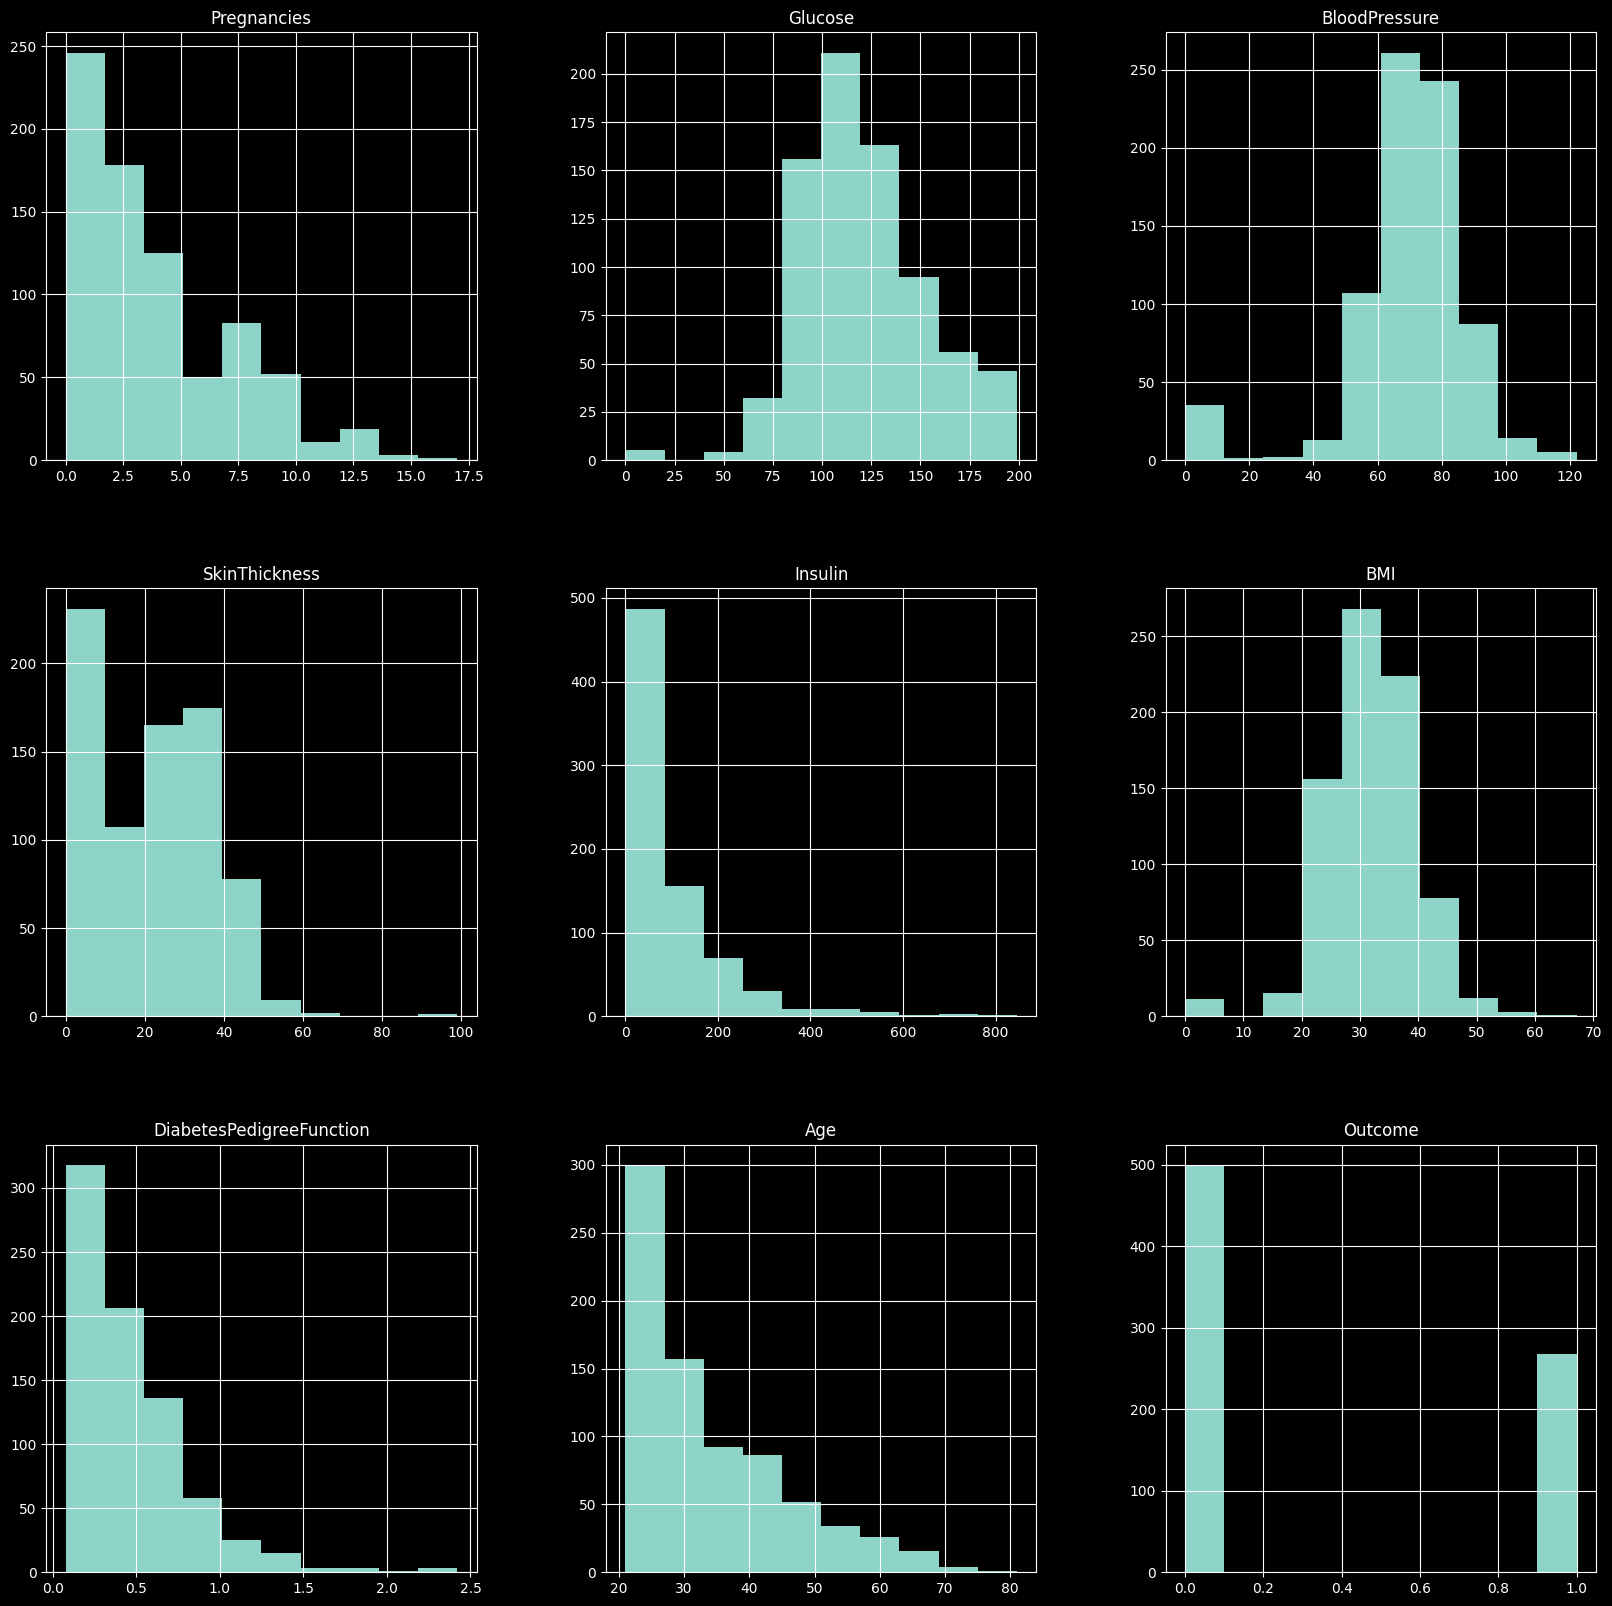

In [12]:
df.hist(figsize=(20,20))
plt.show()

In [14]:
df_copy = df.copy(deep=True)
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)
print(df_copy.isnull().sum())
"now we have some null values"

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


'now we have some null values'

In [15]:
df_copy['Glucose'] = df_copy['Glucose'].fillna(df_copy['Glucose'].mean())
df_copy['BloodPressure'] = df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean())

In [16]:
median_col = ['SkinThickness','Insulin','BMI']

for col in median_col:
    df_copy[col] = df_copy[col].fillna(df_copy[col].median())

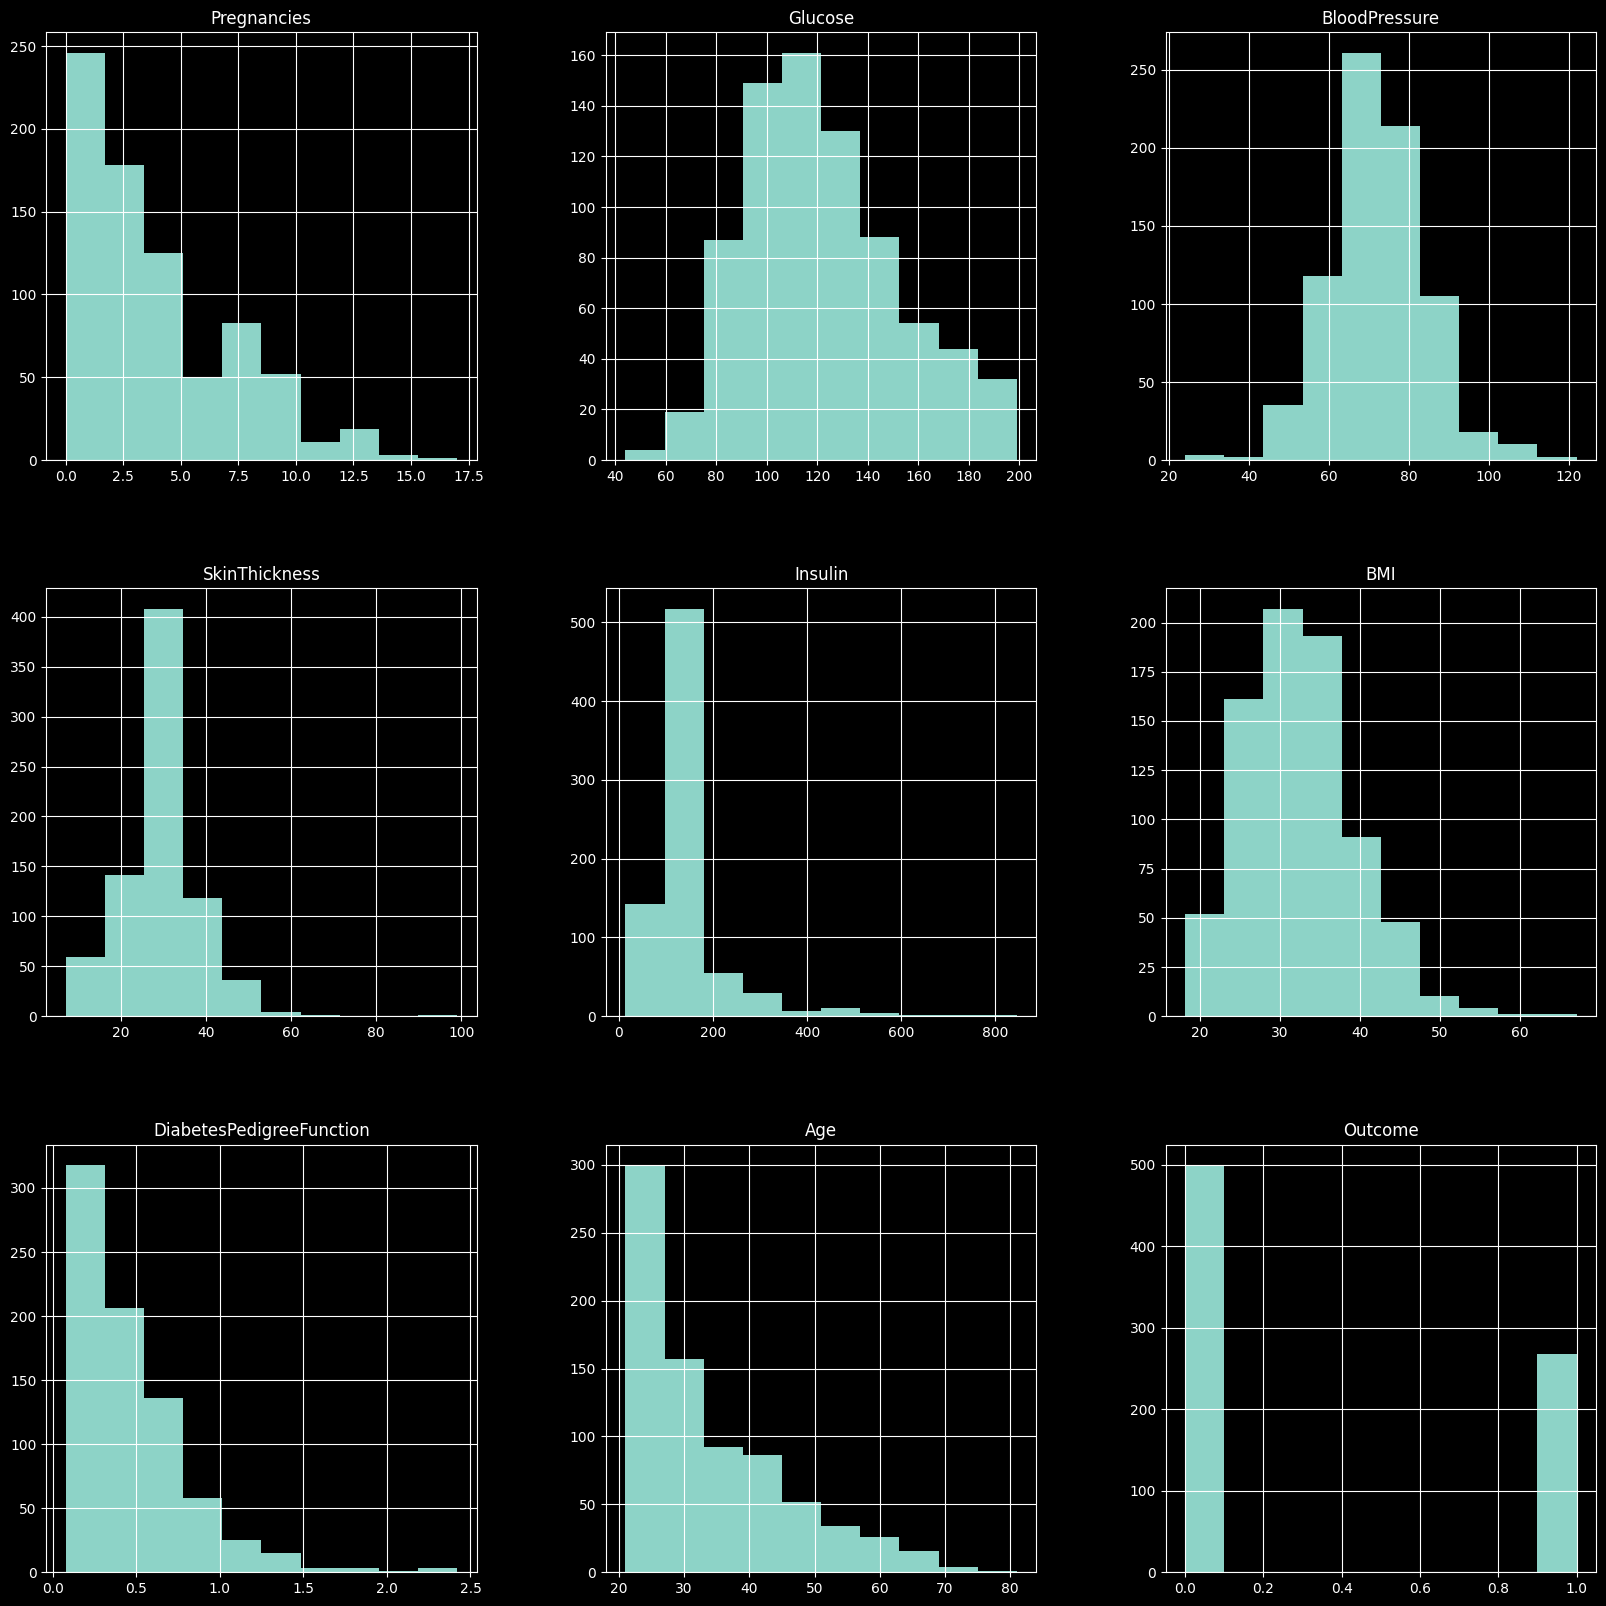

In [17]:
after_nan = df_copy.hist(figsize=(20,20))

In [18]:
df_copy.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.492928
BloodPressure               0.166074
SkinThickness               0.214873
Insulin                     0.203790
BMI                         0.312038
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [19]:
df_copy.corr('spearman')['Outcome']

Pregnancies                 0.198689
Glucose                     0.481630
BloodPressure               0.171652
SkinThickness               0.215702
Insulin                     0.274427
BMI                         0.307039
DiabetesPedigreeFunction    0.175353
Age                         0.309040
Outcome                     1.000000
Name: Outcome, dtype: float64

<Axes: >

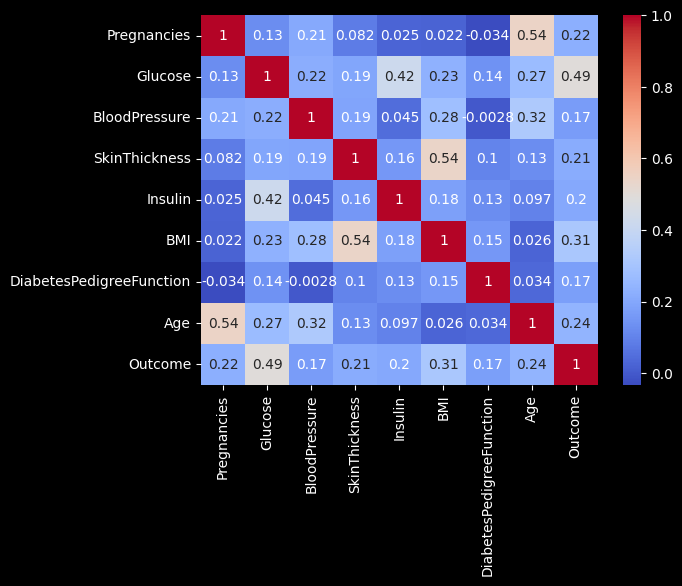

In [20]:
sns.heatmap(df_copy.corr(),annot=True,cmap='coolwarm')
#glucose and outcome
#skinthickness and insulin, BMI
#age and pregnancies

Pregnancies


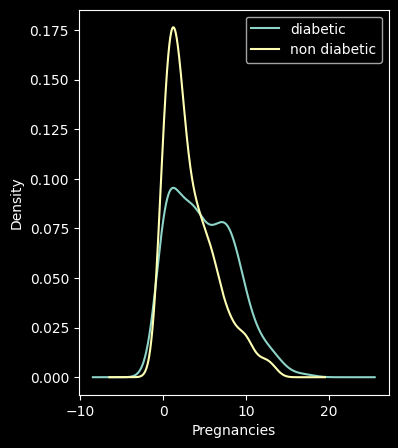

Glucose


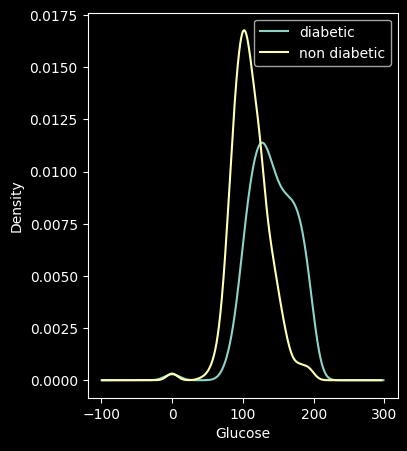

BloodPressure


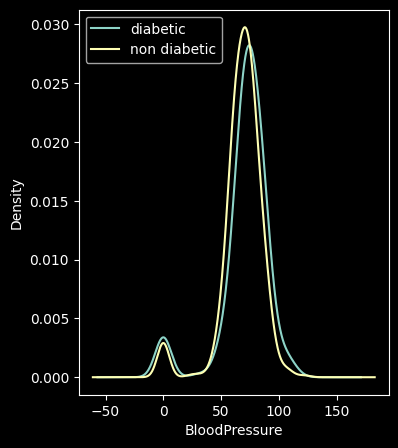

SkinThickness


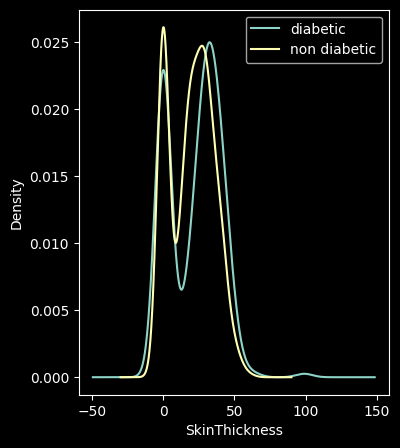

Insulin


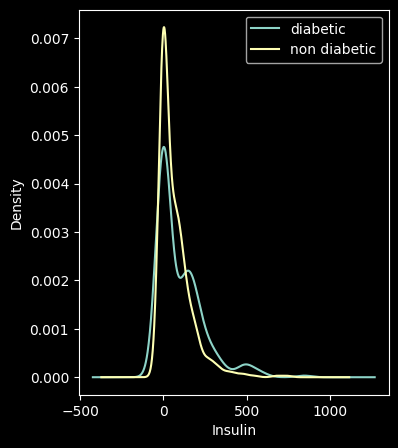

BMI


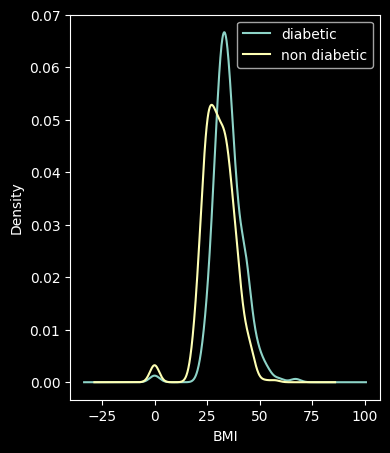

DiabetesPedigreeFunction


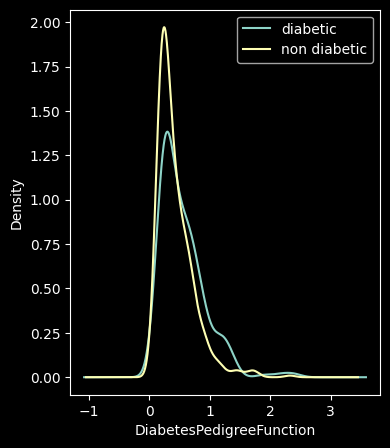

Age


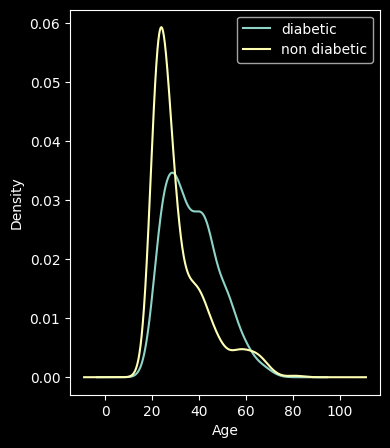

Outcome


In [29]:
for col in df.columns:
    print(col)
    if col != 'Outcome':
        plt.figure(figsize=(4,5))
        df[df_copy['Outcome']==1][col].plot(kind='kde',label='diabetic')
        df[df_copy['Outcome']==0][col].plot(kind='kde',label='non diabetic')
        plt.xlabel(col)
        plt.legend()
        plt.show()

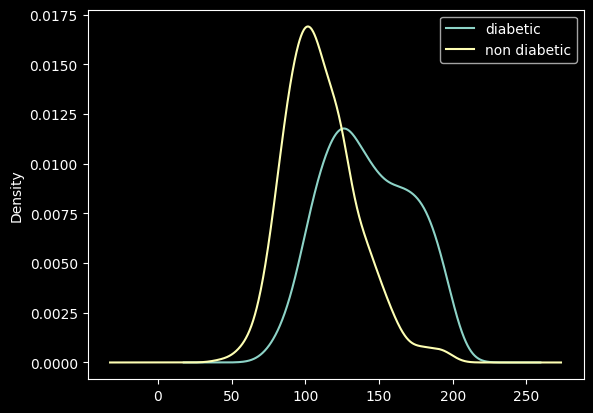

It seems that glucose level above 135 is more common in diabetic patients


In [30]:
df_copy[df_copy['Outcome']==1]['Glucose'].plot(kind='kde',label='diabetic')
df_copy[df_copy['Outcome']==0]['Glucose'].plot(kind='kde',label='non diabetic')
plt.legend()
plt.show()
print("It seems that glucose level above 135 is more common in diabetic patients")

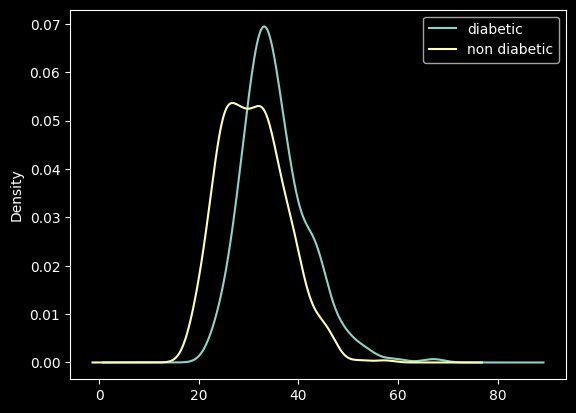

people with BMI above 30(obese) are more likely diabetic


In [31]:
df_copy[df_copy['Outcome']==1]['BMI'].plot(kind='kde',label='diabetic')
df_copy[df_copy['Outcome']==0]['BMI'].plot(kind='kde',label='non diabetic')
plt.legend()
plt.show()
print("people with BMI above 30(obese) are more likely diabetic")

data suffers from outliers


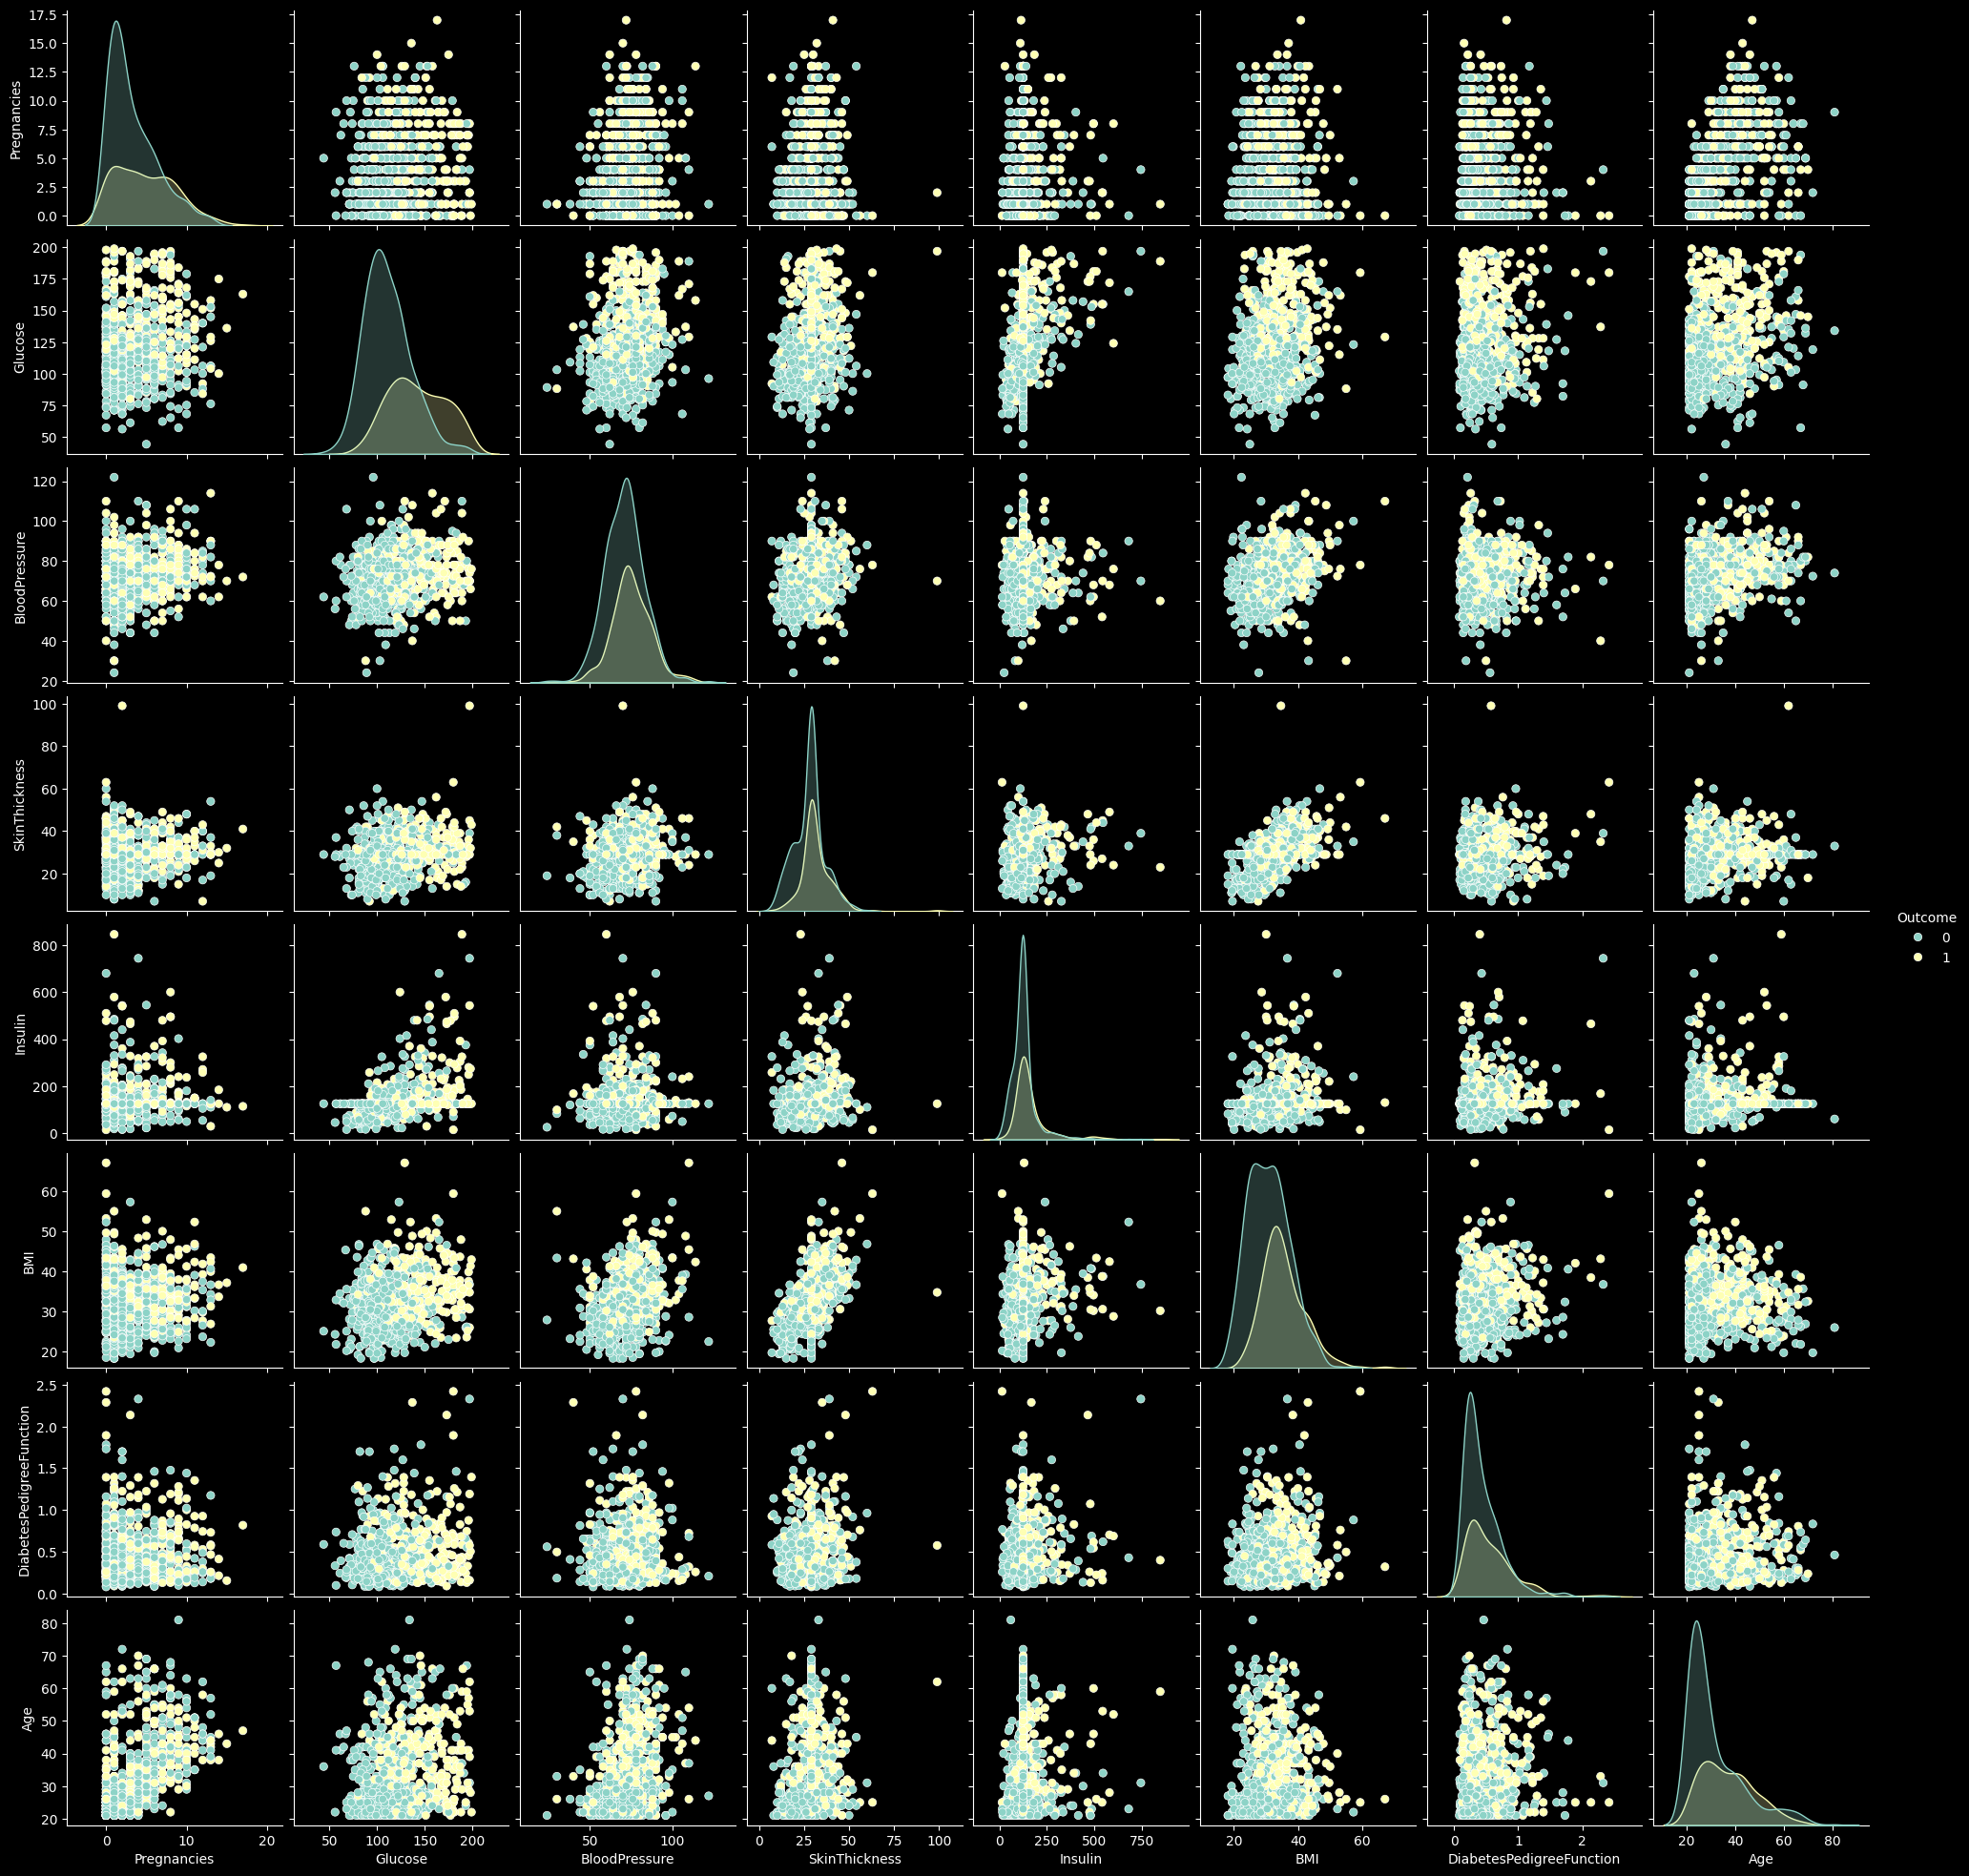

In [32]:
sns.pairplot(df_copy, hue='Outcome')
print("data suffers from outliers")

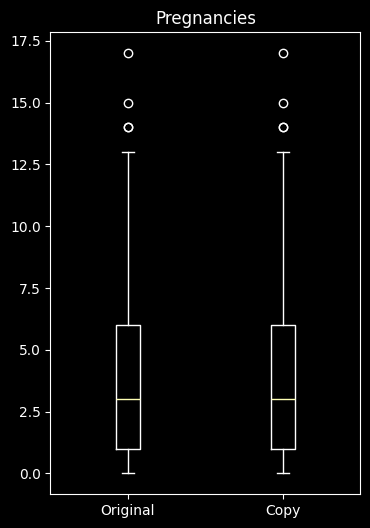

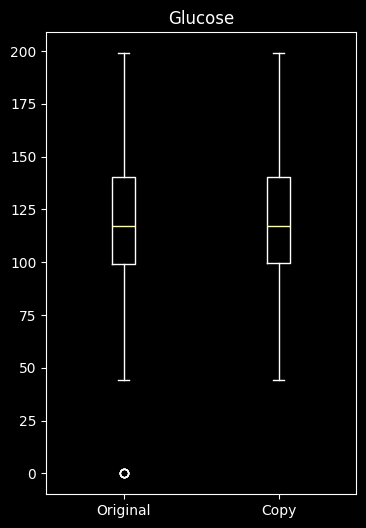

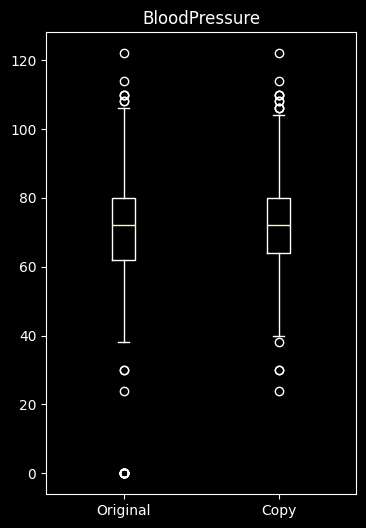

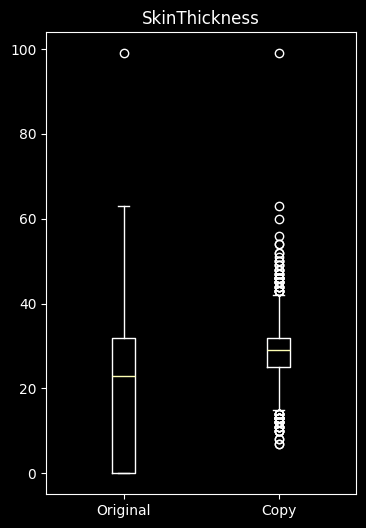

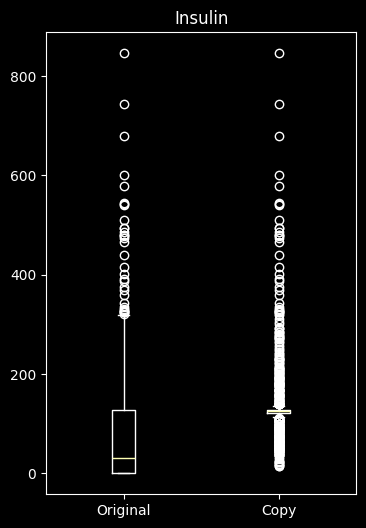

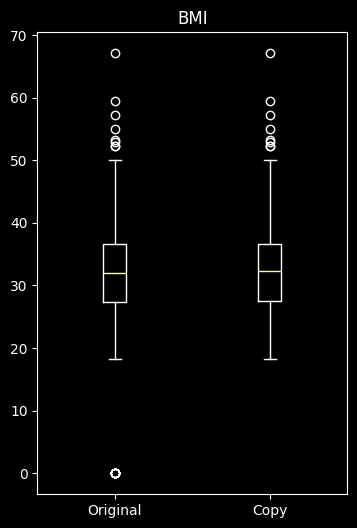

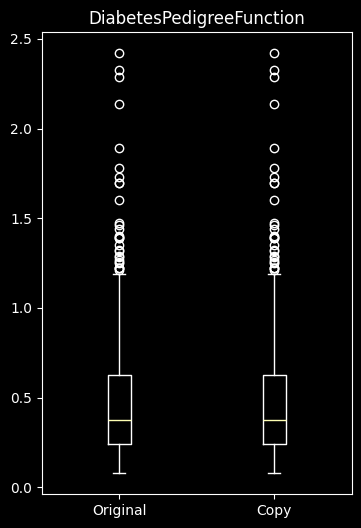

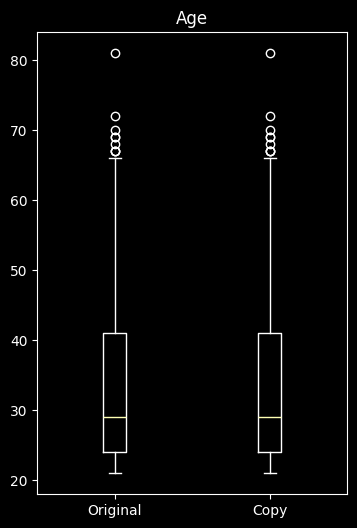

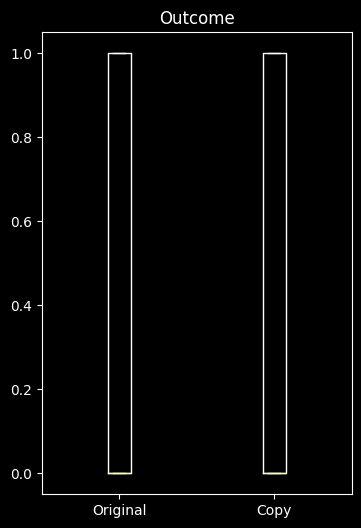

In [33]:
# outlier detection
for col in df_copy.columns:
    plt.figure(figsize=(4, 6))
    plt.boxplot([df[col], df_copy[col]],
                tick_labels=['Original', 'Copy'])
    plt.title(col)
    plt.show()

In [34]:
X = df_copy.drop('Outcome',axis=1)
y = df_copy['Outcome']

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X),columns=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age'])

In [38]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.680125,0.297376,2.150354,0.455573,0.064737,-0.908682,2.532136
764,-0.547919,0.010298,-0.198965,-0.239949,-0.181541,0.632365,-0.398282,-0.531023
765,0.342981,-0.022579,-0.033518,-0.695245,-0.332132,-0.910418,-0.685193,-0.275760
766,-0.844885,0.141808,-1.026200,-0.012301,-0.181541,-0.342790,-0.371101,1.170732


In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [42]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })



In [44]:
results_df = pd.DataFrame(results).sort_values(by=['Recall','F1 Score'],ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.668831,0.525424,0.574074,0.548673
2,Random Forest,0.746753,0.682927,0.518519,0.589474
0,Logistic Regression,0.740260,0.684211,0.481481,0.565217
3,KNN,0.688312,0.565217,0.481481,0.520000
4,SVM,0.727273,0.666667,0.444444,0.533333


### we will tune top 3 models that are rf, lr, knn

### Data Validation

In [45]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Tuning RandomForestClassifier

In [46]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100,200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2,5],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    scoring='recall',
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
y_pred = grid_rf.predict(X_test)

best_rf = grid_rf.best_estimator_

print("best parameters:",grid_rf.best_params_)
print("recall:",recall_score(y_test,y_pred))
    

best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
recall: 0.7407407407407407


In [47]:

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    dt,
    param_grid,
    scoring='recall',
    cv=5
)

grid_dt.fit(X_train, y_train)
y_pred = grid_dt.predict(X_test)

best_dt = grid_dt.best_estimator_

print("Best parameters:", grid_dt.best_params_)
print("Recall:", recall_score(y_test,y_pred))

Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
Recall: 0.5185185185185185


### Tuning Logistic Regression

In [60]:

log_reg = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'l1_ratio' : [0, 1],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    scoring='recall',
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)
y_pred = grid_lr.predict(X_test)

best_lr = grid_lr.best_estimator_

print("Best Logistic Params:", grid_lr.best_params_)
print("recall:",recall_score(y_test, y_pred))


Best Logistic Params: {'C': 0.01, 'class_weight': 'balanced', 'l1_ratio': 0, 'solver': 'liblinear'}
recall: 0.7037037037037037


### Tuning SVM

In [49]:
svm = SVC(probability=True)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    scoring='recall',
    cv=cv,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)
y_pred = grid_svm.predict(X_test)

best_svm = grid_svm.best_estimator_

print("Best parameters:", grid_svm.best_params_)
print("recall:", recall_score(y_test,y_pred))

Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
recall: 0.7592592592592593


### Tuning KNN

In [50]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(3, 25),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # only used if minkowski
}

grid_knn = GridSearchCV(
    knn,
    param_grid,
    scoring='recall',
    cv=5
)

grid_knn.fit(X_train, y_train)
y_pred = grid_knn.predict(X_test)

best_knn = grid_knn.best_estimator_

print("Best parameters:", grid_knn.best_params_)
print("recall:", recall_score(y_test,y_pred))

Best parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
recall: 0.5185185185185185


In [61]:

models = {
    "Logistic Regression (Tuned)": best_lr,
    "SVM (Tuned)": best_svm,
    "Decision Tree(Tuned)": best_dt,
    "Random Forest (Tuned)": best_rf,
    "KNN(Tuned)": best_knn
}

final_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

pd.DataFrame(final_results).sort_values(by="Recall", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score
1,SVM (Tuned),0.681818,0.532468,0.759259,0.625954
3,Random Forest (Tuned),0.772727,0.655738,0.740741,0.695652
0,Logistic Regression (Tuned),0.727273,0.593750,0.703704,0.644068
2,Decision Tree(Tuned),0.701299,0.583333,0.518519,0.549020
4,KNN(Tuned),0.772727,0.756757,0.518519,0.615385


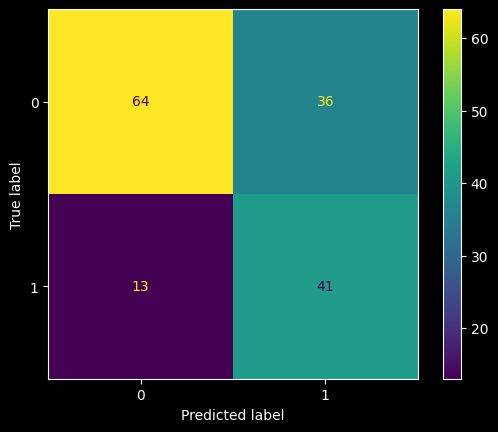

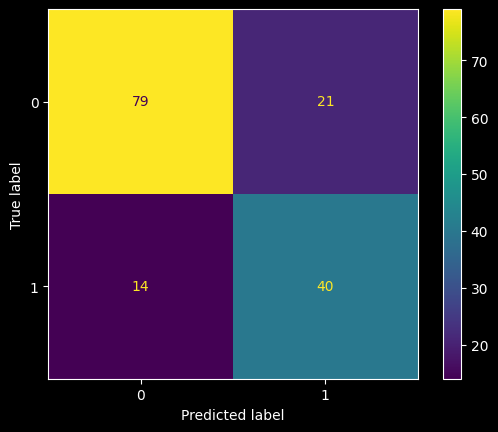

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test)
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)


### Threshold tuning

In [53]:
def tune_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.3, 0.7, 0.05)

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        print(
        f"Threshold {t:.2f} | "
        f"Recall: {recall_score(y_test, y_pred):.3f} | "
        f"F1: {f1_score(y_test, y_pred):.3f} | "
        f"Accuracy: {accuracy_score(y_test,y_pred)}"
        )


In [54]:
tune_threshold(best_svm, X_test, y_test)

Threshold 0.30 | Recall: 0.759 | F1: 0.626 | Accuracy: 0.6818181818181818
Threshold 0.35 | Recall: 0.741 | F1: 0.635 | Accuracy: 0.7012987012987013
Threshold 0.40 | Recall: 0.685 | F1: 0.627 | Accuracy: 0.7142857142857143
Threshold 0.45 | Recall: 0.630 | F1: 0.613 | Accuracy: 0.7207792207792207
Threshold 0.50 | Recall: 0.593 | F1: 0.627 | Accuracy: 0.7532467532467533
Threshold 0.55 | Recall: 0.519 | F1: 0.602 | Accuracy: 0.7597402597402597
Threshold 0.60 | Recall: 0.444 | F1: 0.545 | Accuracy: 0.7402597402597403
Threshold 0.65 | Recall: 0.389 | F1: 0.525 | Accuracy: 0.7532467532467533


In [55]:
tune_threshold(best_rf, X_test, y_test)

Threshold 0.30 | Recall: 0.907 | F1: 0.641 | Accuracy: 0.6428571428571429
Threshold 0.35 | Recall: 0.907 | F1: 0.710 | Accuracy: 0.7402597402597403
Threshold 0.40 | Recall: 0.796 | F1: 0.672 | Accuracy: 0.7272727272727273
Threshold 0.45 | Recall: 0.796 | F1: 0.705 | Accuracy: 0.7662337662337663
Threshold 0.50 | Recall: 0.741 | F1: 0.696 | Accuracy: 0.7727272727272727
Threshold 0.55 | Recall: 0.667 | F1: 0.655 | Accuracy: 0.7532467532467533
Threshold 0.60 | Recall: 0.537 | F1: 0.617 | Accuracy: 0.7662337662337663
Threshold 0.65 | Recall: 0.426 | F1: 0.554 | Accuracy: 0.7597402597402597


In [56]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)


Glucose                     0.330129
BMI                         0.187508
Age                         0.135740
Insulin                     0.114694
DiabetesPedigreeFunction    0.080099
Pregnancies                 0.063708
SkinThickness               0.053466
BloodPressure               0.034657
dtype: float64

In [57]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="recall"
)

print("Mean Recall:", scores.mean())

Mean Recall: 0.7724668064290705


In [58]:
import pickle

In [59]:
with open('model.pkl','wb') as f:
    pickle.dump(best_rf, f)

with open('scaler.pkl','wb') as f:
    pickle.dump(scaler, f)